# Macro Regime–Conditional Risk Monitor — Data Collection
### FINM 35900 Project · Virtu Financial · Group: Antonio, Beckham, Christo, Kevin

This notebook is the **data layer** for the project. It does not do the analysis — it
*collects, cleans, aligns, and caches* every series the roadmap calls for so the
modelling notebooks can start from one tidy parquet/CSV per dataset.

**What the roadmap needs** (and where each piece comes from):

| # | Roadmap analysis | Series | Source |
|---|------------------|--------|--------|
| 1 | Realized equity volatility | SPX / S&P 500 daily returns; VIRT daily returns | WRDS CRSP (`crsp.dsf`), FRED |
| 2 | Implied volatility | VIX; SPX option implied-vol surface | FRED `VIXCLS`, WRDS OptionMetrics |
| 3 | Variance risk premium | VIX² − subsequent realized variance | derived |
| 4 | Vol-of-vol | realized vol of ΔVIX; VVIX | derived, FRED `VVIXCLS` |
| 5 | Liquidity / activity proxies | CRSP volume, NFCI, credit spreads | WRDS CRSP, FRED |
| 6 | Tail behavior | SCOFT diagnostics on returns | derived (NNT techniques) |
| — | Regime-classification inputs | inflation/labor surprises, FOMC direction, yield vol, credit, NFCI | FRED |
| — | Macro release calendar | CPI, FOMC, NFP, GDP dates | FRED ALFRED / release calendar |
| — | Virtu fundamentals | quarterly net trading revenue, cash | WRDS Compustat (`comp.fundq`), SEC |

**Methodological note (why SCOFT / NNT matters here).** Taleb's *Statistical Consequences
of Fat Tails* and *Dynamic Hedging* are the reason this project does **not** simply report
means and standard deviations per regime. Under fat tails, the sample variance and especially
the sample kurtosis can be uninformative — the 4th moment may not even exist for equity
returns, which makes naive "kurtosis per regime" comparisons meaningless. So this notebook
ships a small `nnt_tails` toolkit (Section 9) implementing:

- **MS plot** (maximum-to-sum) — does the p-th moment exist? (SCOFT §2.2.21, Ch.10)
- **Mean-excess plot** — linear increase ⇒ power-law / fat tail (SCOFT §10, mean-excess)
- **Hill / log-log tail exponent α** — how fat is the tail (SCOFT Ch.5, Ch.9)
- **Kurtosis under aggregation** — instability of the 4th moment (SCOFT §10.2.1)
- **Right-vs-left tail asymmetry** (SCOFT §10.2.8)

From *Dynamic Hedging* we take the framing that drives the *variance risk premium* and
*vol-of-vol* work: a market maker's danger is not volatility per se but **gamma/vega
exposure when realized volatility outruns the implied vol it hedged at** — i.e. when
short-gamma inventory has to be rebalanced into a moving market. The VRP and the
realized−implied gap (Section 6) are the empirical handle on exactly that.


## 0 · Setup

Install once (uncomment). `wrds` handles the WRDS connection; `pandas-datareader` pulls FRED
without an API key. Everything is cached to `./data/` so you only hit the servers once.

In [1]:
# !pip install wrds pandas-datareader pandas numpy pyarrow matplotlib scipy

import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

DATA_DIR = Path("./data")
RAW = DATA_DIR / "raw"
CLEAN = DATA_DIR / "clean"
for d in (RAW, CLEAN):
    d.mkdir(parents=True, exist_ok=True)

# Project sample window. Roadmap/proposal used 2019–2024 for Virtu filings; we pull a
# longer market window so tail/regime estimation has enough data (SCOFT Ch.8: fat-tailed
# samples need *far* more observations than thin-tailed ones for stable moments).
START = "2006-01-01"     # covers '08, the euro crisis, taper tantrum, COVID, 2022 hikes
END   = "2025-12-31"
print(f"Sample: {START} to {END}")


Sample: 2006-01-01 to 2025-12-31


## 1 · Connect to WRDS

You'll be prompted for your WRDS username/password the first time. Choosing to create a
`.pgpass` file when prompted means you won't have to log in again on this machine.

> Library and table names are **case-sensitive and lowercase** on WRDS.

In [3]:
import wrds

# Pass your username, or omit to be prompted. After first login, accept the .pgpass
# prompt so future connections are automatic.
db = wrds.Connection(wrds_username=os.environ.get("WRDS_USERNAME"))  # or wrds.Connection()

# Sanity check — what do we have access to? (uncomment to browse)
# print(db.list_libraries()[:50])
# print(db.list_tables(library="optionm"))     # OptionMetrics
# print(db.list_tables(library="crsp"))


WRDS recommends setting up a .pgpass file.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


## 2 · FRED block (no API key needed)

FRED gives us, in one place: VIX, VVIX, the macro level series for regime classification,
credit spreads, financial-conditions, and the raw inputs for "surprises." We pull everything
in one dict so it's easy to extend.

`pandas_datareader` reads FRED directly. If your network blocks it, the CSV fallback URL
pattern is `https://fred.stlouisfed.org/graph/fredgraph.csv?id=SERIES`.

In [27]:
import pandas_datareader.data as web

FRED_SERIES = {
    # --- implied vol / vol-of-vol (roadmap #2, #4) ---
    "VIXCLS":   "VIX (CBOE implied vol, %)",
    "VVIX":     "VVIX (vol-of-vol)",            # was VVIXCLS — wrong; FRED ID is VVIX
    "VXVCLS":   "VXV (3-month VIX)",            # if this shows XX too, FRED discontinued it
    # --- rates / yield-vol inputs for regime + Treasury vol (roadmap regime vars) ---
    "DGS10":    "10Y Treasury yield",
    "DGS2":     "2Y Treasury yield",
    "DGS3MO":   "3M Treasury yield",
    "DFEDTARU": "Fed funds target upper bound",      # FOMC policy direction
    "T10Y2Y":   "10Y-2Y term spread",
    # --- credit / financial conditions (roadmap: credit spreads, FCIs) ---
    "BAMLH0A0HYM2": "ICE BofA US High-Yield OAS",
    "BAMLC0A0CM":   "ICE BofA US IG corporate OAS",
    "BAA10Y":   "Moody's Baa - 10Y Treasury spread (full history, ICE-free)",
    "AAA10Y":   "Moody's Aaa - 10Y Treasury spread",
    "BAA":      "Moody's Baa corporate yield",
    "AAA":      "Moody's Aaa corporate yield",
    "NFCI":         "Chicago Fed NFCI (financial conditions)",
    "ANFCI":        "Adjusted NFCI",
    "STLFSI4":      "St Louis Fed Financial Stress Index",
    "TEDRATE":      "TED spread (legacy, ends 2022)",
    # --- macro levels for surprise construction (roadmap: inflation/labor surprises) ---
    "CPIAUCSL": "CPI all-urban (level, for YoY)",
    "PCEPILFE": "Core PCE price index",
    "UNRATE":   "Unemployment rate",
    "PAYEMS":   "Nonfarm payrolls (level)",
    "GDPC1":    "Real GDP (quarterly)",
    "INDPRO":   "Industrial production",
    # --- equity index (backup to CRSP) ---
    "SP500":    "S&P 500 index (last 10y, daily)",
}

def fetch_fred(series_dict, start=START, end=END):
    out = {}
    for code_, label in series_dict.items():
        try:
            s = web.DataReader(code_, "fred", start, end)[code_]
            out[code_] = s
            print(f"  ok  {code_:12s} {label:40s} {s.dropna().index.min().date()} → {s.dropna().index.max().date()}  n={s.dropna().shape[0]}")
        except Exception as e:
            print(f"  XX  {code_:12s} FAILED: {e}")
    df = pd.DataFrame(out)
    return df

fred = fetch_fred(FRED_SERIES)
fred.to_parquet(RAW / "fred_raw.parquet")
fred.tail()


  ok  VIXCLS       VIX (CBOE implied vol, %)                2006-01-03 → 2025-12-31  n=5058
  XX  VVIX         FAILED: Unable to read URL: https://fred.stlouisfed.org/graph/fredgraph.csv?id=VVIX
Response Text:
b'<!DOCTYPE html>\r\n<html lang="en">\r\n<head>\r\n    <meta charset="utf-8">\r\n    <meta http-equiv="X-UA-Compatible" content="IE=edge">\r\n    <meta name="viewport" content="width=device-width, initial-scale=1">\r\n    <title>Error - St. Louis Fed</title>\r\n    <meta name="description" content="">\r\n    <meta name="keywords" content="">    \r\n    <link rel="stylesheet" type="text/css" href="/assets/bootstrap/dist/css/bootstrap.min.css">\r\n    <link rel="stylesheet" type="text/css" href="/css/home.min.css?1553087253">\r\n    <link rel="stylesheet" type="text/css" href="/assets/fontawesome-free/css/all.min.css">\r\n    <link rel="stylesheet" type="text/css" href="/assets/select2/dist/css/select2.min.css">\r\n    <style>p {\r\n        margin-bottom: 1.5em;\r\n    }</style>\r\

,VIXCLS,VXVCLS,DGS10,DGS2,DGS3MO,DFEDTARU,T10Y2Y,BAMLH0A0HYM2,BAMLC0A0CM,BAA10Y,...,ANFCI,STLFSI4,TEDRATE,CPIAUCSL,PCEPILFE,UNRATE,PAYEMS,GDPC1,INDPRO,SP500
DATE,,,,,,,,,,,,,,,,,,,,,
2025-12-27,NaN,NaN,NaN,NaN,NaN,3.75,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-12-28,NaN,NaN,NaN,NaN,NaN,3.75,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-12-29,14.20,17.82,4.12,3.45,3.68,3.75,0.67,2.87,0.79,1.76,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6905.74
2025-12-30,14.33,17.77,4.14,3.45,3.65,3.75,0.69,2.84,0.79,1.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6896.24
2025-12-31,14.95,18.18,4.18,3.47,3.67,3.75,0.71,2.81,0.79,1.72,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6845.50


## 3 · Equity index & stock returns from WRDS CRSP (roadmap #1)

> **CRSP schema note (this is why `crsp.dsi`/`caldt` errored).** In 2024–25 CRSP migrated
> from the legacy *flat-file 1.0 (SIZ)* tables to *flat-file 2.0 (CIZ)*. WRDS renamed the
> tables (`_v2` suffix) and **renamed the columns**, and many subscriptions have dropped the
> old SIZ tables — so `crsp.dsi` with `caldt` no longer resolves. The cell below **discovers**
> what your subscription actually exposes, then we query the v2 tables with the new column
> names (`dlycaldt`, `dlyret`, `dlyprc`, `dlyvol`, …) and fall back to legacy names only if the
> v2 tables aren't present.

We use the **CRSP daily market index** for the value-weighted market return, the **S&P 500
index** series, and **Virtu (VIRT)** as an individual stock so we can study the market maker's
*own* return tails.

In [5]:
# 3a. DISCOVER what CRSP tables/columns your subscription exposes (run once).
#     This avoids hard-coding names that differ between the legacy SIZ and new CIZ formats.
crsp_tables = db.list_tables(library="crsp")
def has(t): return t in crsp_tables
print("daily stock file present:",
      {t: has(t) for t in ["dsf_v2", "dsf", "stkdsecuritydata"]})
print("daily index file present:",
      {t: has(t) for t in ["dsi_v2", "dsi", "stkmktindexdaily", "mktindexdaily"]})

# Helper: print columns of a table so you can confirm names if a query fails.
def cols(table, library="crsp"):
    return list(db.describe_table(library=library, table=table)["name"])

# Show the index-file columns we'll rely on (uncomment whichever exists):
for t in ["dsi_v2", "dsi"]:
    if has(t):
        print(f"\ncrsp.{t} columns:", cols(t)); break


daily stock file present: {'dsf_v2': True, 'dsf': True, 'stkdsecuritydata': False}
daily index file present: {'dsi_v2': False, 'dsi': True, 'stkmktindexdaily': False, 'mktindexdaily': False}
Approximately 26051 rows in crsp.dsi.

crsp.dsi columns: ['date', 'vwretd', 'vwretx', 'ewretd', 'ewretx', 'sprtrn', 'spindx', 'totval', 'totcnt', 'usdval', 'usdcnt']


In [6]:
# 3b. CRSP daily MARKET index (value-weighted). Column names differ by format:
#   CIZ (v2):   date col = caldt OR dlycaldt; vw return = vwretd (often retained) or
#               sprtrn for the S&P. Index tables in CIZ are e.g. crsp.dsi_v2.
#   SIZ (old):  crsp.dsi with caldt, vwretd, vwretx, ewretd, sprtrn, totval, totcnt.
# We try v2 first, then legacy. Inspect cols() output above and adjust the SELECT if needed.

def try_sql(sql):
    try:
        return db.raw_sql(sql, date_cols=[c for c in ["caldt","dlycaldt","date"] if c in sql])
    except Exception as e:
        print("  query failed:", str(e).splitlines()[0]); return None

crsp_mkt = None
candidates = [
    # (table, date_col, value-weighted-return col)
    ("dsi_v2", "caldt",    "vwretd"),
    ("dsi_v2", "dlycaldt", "vwretd"),
    ("dsi",    "caldt",    "vwretd"),
]
for tbl, dcol, vw in candidates:
    if tbl not in crsp_tables:
        continue
    avail = cols(tbl)
    dcol = dcol if dcol in avail else next((c for c in ["caldt","dlycaldt","date"] if c in avail), None)
    vw   = vw   if vw   in avail else next((c for c in ["vwretd","vwretx","sprtrn"] if c in avail), None)
    sel  = [c for c in [dcol, vw, "sprtrn", "ewretd", "totval", "totcnt"] if c in avail]
    sql = f"select {', '.join(sel)} from crsp.{tbl} where {dcol} between '{START}' and '{END}'"
    print(f"trying crsp.{tbl} -> select {sel}")
    crsp_mkt = try_sql(sql)
    if crsp_mkt is not None and len(crsp_mkt):
        crsp_mkt = crsp_mkt.rename(columns={dcol: "date", vw: "vwretd"}).set_index("date").sort_index()
        print(f"  ok: {crsp_mkt.shape} from crsp.{tbl}")
        break

assert crsp_mkt is not None and len(crsp_mkt), \
    "No market-index table resolved. Check cols() output above and edit the candidates list."
crsp_mkt.to_parquet(RAW / "crsp_market_index.parquet")
crsp_mkt.head()


Approximately 26051 rows in crsp.dsi.
trying crsp.dsi -> select ['date', 'vwretd', 'sprtrn', 'ewretd', 'totval', 'totcnt']
  ok: (4781, 5) from crsp.dsi


,vwretd,sprtrn,ewretd,totval,totcnt
date,,,,,
2006-01-03,0.016406,0.016431,0.010981,17626361100.0,6742
2006-01-04,0.005523,0.003673,0.007697,17718789600.0,6739
2006-01-05,-0.000334,0.000016,0.00292,17712009300.0,6736
2006-01-06,0.009805,0.009399,0.009032,17881128600.0,6734
2006-01-09,0.004312,0.003656,0.007009,17950109500.0,6728


In [7]:
# 3c. S&P 500 composite. In CIZ this commonly lives in crsp.dsp500_v2 (or sprtrn already
#     carries the S&P daily return in the index file above). Try the dedicated table; if it
#     isn't on your subscription, just use sprtrn from crsp_mkt.
sp500 = None
for tbl in ["dsp500_v2", "dsp500"]:
    if tbl in crsp_tables:
        avail = cols(tbl)
        dcol = next((c for c in ["caldt", "dlycaldt", "date"] if c in avail), None)
        sel = [c for c in [dcol, "spindx", "sprtrn"] if c in avail]
        try:
            sp500 = db.raw_sql(
                f"select {', '.join(sel)} from crsp.{tbl} where {dcol} between '{START}' and '{END}'",
                date_cols=[dcol]).rename(columns={dcol: "date"}).set_index("date").sort_index()
            sp500.to_parquet(RAW / "crsp_sp500.parquet")
            print(f"S&P 500 index file crsp.{tbl}:", sp500.shape)
            break
        except Exception as e:
            print(f"crsp.{tbl} failed:", str(e).splitlines()[0])
if sp500 is None:
    print("Using sprtrn from the market index file as the S&P 500 return series.")
    if "sprtrn" in crsp_mkt.columns:
        sp500 = crsp_mkt[["sprtrn"]].copy()
sp500.head() if sp500 is not None else None


Approximately 26301 rows in crsp.dsp500_v2.
S&P 500 index file crsp.dsp500_v2: (5031, 2)


,spindx,sprtrn
date,,
2006-01-03,1268.8,0.016431
2006-01-04,1273.46,0.003673
2006-01-05,1273.48,0.000016
2006-01-06,1285.45,0.009399
2006-01-09,1290.15,0.003656


In [8]:
# 3d. Find Virtu's PERMNO. In CIZ the names/security-info table is
#     crsp.stksecurityinfohist (or stocknames_v2); legacy was crsp.dsenames.
virt_permno = None
name_candidates = [
    ("stksecurityinfohist", "ticker", "securitynm", "secinfostartdt", "secinfoenddt"),
    ("stocknames_v2",       "ticker", "comnam",     "namedt",         "nameenddt"),
    ("stocknames",          "ticker", "comnam",     "namedt",         "nameenddt"),
    ("dsenames",            "ticker", "comnam",     "namedt",         "nameenddt"),
]
for tbl, tcol, ncol, sdt, edt in name_candidates:
    if tbl not in crsp_tables:
        continue
    avail = cols(tbl)
    ncol = ncol if ncol in avail else next((c for c in ["securitynm","comnam","issuernm"] if c in avail), None)
    sel  = [c for c in ["permno", tcol, ncol, sdt, edt] if c in avail]
    try:
        vn = db.raw_sql(f"select {', '.join(sel)} from crsp.{tbl} where {tcol} = 'VIRT'")
        print(f"crsp.{tbl}:\n", vn.to_string())
        if len(vn):
            mask = vn[ncol].astype(str).str.contains("VIRTU", case=False, na=False) if ncol else slice(None)
            sub = vn.loc[mask] if ncol else vn
            virt_permno = int((sub if len(sub) else vn)["permno"].iloc[0])
            print("VIRT permno:", virt_permno); break
    except Exception as e:
        print(f"crsp.{tbl} failed:", str(e).splitlines()[0])
assert virt_permno, "Could not resolve VIRT permno — inspect the printed name table."


Approximately 191048 rows in crsp.stksecurityinfohist.
crsp.stksecurityinfohist:
    permno ticker                        securitynm secinfostartdt secinfoenddt
0   15302   VIRT  VIRTU FINANCIAL INC; COM A; CONS     2015-04-16   2015-06-25
1   15302   VIRT  VIRTU FINANCIAL INC; COM A; CONS     2015-06-26   2019-09-11
2   15302   VIRT  VIRTU FINANCIAL INC; COM A; CONS     2019-09-12   2023-09-28
3   15302   VIRT  VIRTU FINANCIAL INC; COM A; CONS     2023-09-29   2023-09-30
4   15302   VIRT  VIRTU FINANCIAL INC; COM A; CONS     2023-10-01   2025-06-16
5   15302   VIRT  VIRTU FINANCIAL INC; COM A; CONS     2025-06-17   2025-12-31
VIRT permno: 15302


In [9]:
# 3e. Virtu daily prices/returns/volume. CIZ daily stock file = crsp.dsf_v2 with renamed
#     columns: dlycaldt (date), dlyret (return), dlyprc (price), dlyvol (volume),
#     dlyopen/dlyhigh/dlylow. Legacy SIZ = crsp.dsf with date/ret/prc/vol/openprc/askhi/bidlo.
virt = None
stk_candidates = [
    # table, {logical: actual} column map
    ("dsf_v2", {"date":"dlycaldt","ret":"dlyret","prc":"dlyprc","vol":"dlyvol",
                "open":"dlyopen","high":"dlyhigh","low":"dlylow"}),
    ("dsf",    {"date":"caldt","ret":"ret","prc":"prc","vol":"vol",
                "open":"openprc","high":"askhi","low":"bidlo"}),
]
for tbl, m in stk_candidates:
    if tbl not in crsp_tables:
        continue
    avail = cols(tbl)
    m = {k: v for k, v in m.items() if v in avail}
    sel = ["permno"] + list(m.values())
    try:
        v = db.raw_sql(
            f"select {', '.join(sel)} from crsp.{tbl} "
            f"where permno = {virt_permno} and {m['date']} between '{START}' and '{END}'",
            date_cols=[m["date"]])
        inv = {val: key for key, val in m.items()}
        virt = v.rename(columns=inv).set_index("date").sort_index()
        virt["prc"] = virt["prc"].abs()  # CRSP stores negative prc for bid/ask midpoints
        print(f"VIRT daily from crsp.{tbl}:", virt.shape,
              virt.index.min().date(), "->", virt.index.max().date())
        break
    except Exception as e:
        print(f"crsp.{tbl} failed:", str(e).splitlines()[0])
assert virt is not None and len(virt), "VIRT daily query failed — check column map vs cols('dsf_v2')."
virt.to_parquet(RAW / "virt_daily.parquet")
virt[[c for c in ["prc","ret","vol"] if c in virt.columns]].describe()


Approximately 110257376 rows in crsp.dsf_v2.
VIRT daily from crsp.dsf_v2: (2695, 7) 2015-04-16 -> 2025-12-31


,prc,ret,vol
count,2695.0,2694.0,2695.0
mean,24.073263,0.00056,964982.994434
std,6.880365,0.022162,823806.010932
min,12.55,-0.181487,41080.0
25%,18.42,-0.010652,529838.5
50%,22.75,0.000598,824000.0
75%,27.585,0.011683,1188902.5
max,45.12,0.321696,16434622.0


## 4 · Implied-vol surface from WRDS OptionMetrics (roadmap #2)

VIX alone is fine for a first pass, but OptionMetrics lets you do the *real* variance-risk-premium
and skew work the roadmap hints at: 30-day interpolated implied vol, the IV term structure, and
risk-reversal/skew measures that pick up the **tail pricing** in options — directly relevant to the
SCOFT angle (are options pricing the left tail?).

`optionm.opd200x` are the daily option-price tables (one per year in some vintages);
`optionm.vsurfd` is the **volatility surface** (interpolated IV by delta & maturity), which is
usually what you want. SPX SECID is **108105**.

In [28]:
# 4a/4b. Find the OptionMetrics volatility-surface table on YOUR subscription.
# WRDS reorganized OptionMetrics into versioned libraries (e.g. optionm_all, optionm_2023,
# wrds_oommetrics), so bare 'optionm.vsurfd' no longer resolves. Discover it.
spx_secid = 108105  # S&P 500 index in OptionMetrics

# Candidate libraries that hold IvyDB US, in rough order of likelihood.
om_lib_candidates = ["optionm_all", "optionm", "wrds_oommetrics", "optionmetrics"]
om_libs = [l for l in db.list_libraries() if any(k in l for k in
           ["optionm", "ivydb", "oommetric"])]
print("OptionMetrics-like libraries on your subscription:", om_libs)

# Pick the first candidate that actually exists, else first discovered lib.
OM_LIB = next((l for l in om_lib_candidates if l in om_libs), om_libs[0] if om_libs else None)
assert OM_LIB, "No OptionMetrics library found — you may not be subscribed."
print("Using library:", OM_LIB)

# The surface table is usually 'vsurfd' (daily vol surface). It may be a single table or
# year-partitioned (vsurfd1996...vsurfd2024). List what's there.
om_tables = db.list_tables(library=OM_LIB)
surf_tables = sorted(t for t in om_tables if t.startswith("vsurf"))
print("surface tables:", surf_tables[:5], "..." if len(surf_tables) > 5 else "")

OptionMetrics-like libraries on your subscription: ['optionm', 'optionm_all', 'optionmsamp_europe', 'optionmsamp_us', 'wrdsapps_link_crsp_optionm']
Using library: optionm_all
surface tables: ['vsurfd1996', 'vsurfd1997', 'vsurfd1998', 'vsurfd1999', 'vsurfd2000'] ...


In [29]:
# 4b(cont). Pull the SPX 30/60/91/182-day surface, handling either a single table or
# year-partitioned tables. Confirm column names first (they're stable: date, days, delta,
# impl_volatility, cp_flag — but check if the query complains).
def surf_cols(tbl):
    return list(db.describe_table(library=OM_LIB, table=tbl)["name"])

if "vsurfd" in surf_tables:                       # single combined table
    print("columns:", surf_cols("vsurfd"))
    ivsurf = db.raw_sql(f"""
        select date, days, delta, impl_volatility, cp_flag
        from {OM_LIB}.vsurfd
        where secid = {spx_secid}
          and date between '{START}' and '{END}'
          and days in (30, 60, 91, 182)
    """, date_cols=["date"])
else:                                             # year-partitioned: vsurfd1996, vsurfd1997...
    yrs = range(int(START[:4]), int(END[:4]) + 1)
    parts = [t for t in surf_tables if t[-4:].isdigit() and int(t[-4:]) in yrs]
    print("pulling partitions:", parts)
    frames = []
    for t in parts:
        frames.append(db.raw_sql(f"""
            select date, days, delta, impl_volatility, cp_flag
            from {OM_LIB}.{t}
            where secid = {spx_secid}
              and days in (30, 60, 91, 182)
        """, date_cols=["date"]))
    ivsurf = pd.concat(frames, ignore_index=True)

ivsurf = ivsurf[(ivsurf["date"] >= START) & (ivsurf["date"] <= END)]
ivsurf.to_parquet(RAW / "spx_ivsurface.parquet")
print("SPX IV surface:", ivsurf.shape)
ivsurf.head()

pulling partitions: ['vsurfd2006', 'vsurfd2007', 'vsurfd2008', 'vsurfd2009', 'vsurfd2010', 'vsurfd2011', 'vsurfd2012', 'vsurfd2013', 'vsurfd2014', 'vsurfd2015', 'vsurfd2016', 'vsurfd2017', 'vsurfd2018', 'vsurfd2019', 'vsurfd2020', 'vsurfd2021', 'vsurfd2022', 'vsurfd2023', 'vsurfd2024', 'vsurfd2025']
SPX IV surface: (672656, 5)


,date,days,delta,impl_volatility,cp_flag
0,2006-01-03,30.0,-90.0,0.135591,P
1,2006-01-03,30.0,-85.0,0.124488,P
2,2006-01-03,30.0,-80.0,0.115049,P
3,2006-01-03,30.0,-75.0,0.108887,P
4,2006-01-03,30.0,-70.0,0.106455,P


In [30]:
# 4c. Standardized 30-day ATM implied vol series.
# OptionMetrics delta is on a -100..+100 scale: calls positive, puts negative.
# ATM call ≈ delta +50, ATM put ≈ delta -50. Confirm the scale on your pull:
print("delta values present:", sorted(ivsurf["delta"].unique()))
print("cp_flags present:", ivsurf["cp_flag"].unique())

# Take the 30-day surface, average the +50 call and -50 put IV for a clean ATM series.
atm = ivsurf[(ivsurf["days"] == 30) & (ivsurf["delta"].abs().between(45, 55))]
atm_iv = atm.groupby("date")["impl_volatility"].mean().rename("spx_iv_30d_atm")

atm_iv.to_frame().to_parquet(CLEAN / "spx_iv_30d_atm.parquet")
print(f"\nATM 30d IV: {atm_iv.shape[0]} days, "
      f"{atm_iv.index.min().date()} → {atm_iv.index.max().date()}")
atm_iv.describe()

delta values present: [np.float64(-90.0), np.float64(-85.0), np.float64(-80.0), np.float64(-75.0), np.float64(-70.0), np.float64(-65.0), np.float64(-60.0), np.float64(-55.0), np.float64(-50.0), np.float64(-45.0), np.float64(-40.0), np.float64(-35.0), np.float64(-30.0), np.float64(-25.0), np.float64(-20.0), np.float64(-15.0), np.float64(-10.0), np.float64(10.0), np.float64(15.0), np.float64(20.0), np.float64(25.0), np.float64(30.0), np.float64(35.0), np.float64(40.0), np.float64(45.0), np.float64(50.0), np.float64(55.0), np.float64(60.0), np.float64(65.0), np.float64(70.0), np.float64(75.0), np.float64(80.0), np.float64(85.0), np.float64(90.0)]
cp_flags present: <StringArray>
['P', 'C']
Length: 2, dtype: string

ATM 30d IV: 4946 days, 2006-01-03 → 2025-08-29


count      4946.0
mean     0.167203
std      0.080172
min      0.065378
25%       0.11456
50%       0.14445
75%      0.196353
max      0.762512
Name: spx_iv_30d_atm, dtype: Float64

## 5 · Virtu fundamentals from WRDS Compustat (roadmap: link to financials)

The proposal connects market stress to Virtu's **quarterly net trading revenue and cash
buffers** from 10-K/10-Q. Compustat quarterly (`comp.fundq`) gives a clean, machine-readable
version of those filings. Virtu's ticker is `VIRT`; we find its `gvkey` first.

In [23]:
virt_gvkey = db.raw_sql("""
    select distinct gvkey, tic, conm
    from comp.names
    where tic = 'VIRT'
""")
print(virt_gvkey.to_string())
gvkey = virt_gvkey.gvkey.iloc[0]

fund_q = db.raw_sql(f"""
    select gvkey, datadate, fyearq, fqtr, tic, conm,
           revtq,        -- total revenue
           cogsq,        -- cost of goods sold
           niq,          -- net income
           cheq,         -- cash & equivalents (cash buffer proxy)
           atq, ltq,     -- assets / liabilities
           seqq,         -- stockholders equity
           xoprq         -- operating expense
    from comp.fundq
    where gvkey = '{gvkey}'
      and datadate between '{START}' and '{END}'
      and datafmt = 'STD' and consol = 'C' and indfmt = 'INDL'
    order by datadate
""", date_cols=["datadate"])
fund_q.to_parquet(RAW / "virt_fundamentals_q.parquet")
print("Virtu quarterly fundamentals:", fund_q.shape)
fund_q[["datadate", "fyearq", "fqtr", "revtq", "niq", "cheq"]].tail(12)


    gvkey   tic                 conm
0  023432  VIRT  VIRTU FINANCIAL INC
Virtu quarterly fundamentals: (52, 14)


,datadate,fyearq,fqtr,revtq,niq,cheq
40,2023-03-31,2023,1,620.38,57.881,1670.057
41,2023-06-30,2023,2,506.853,16.701,1714.682
42,2023-09-30,2023,3,630.163,61.916,4032.486
43,2023-12-31,2023,4,535.977,5.538,2549.582
44,2024-03-31,2024,1,642.839,55.817,931.876
45,2024-06-30,2024,2,692.985,66.586,1509.955
46,2024-09-30,2024,3,706.84,59.952,1618.655
47,2024-12-31,2024,4,834.285,94.06,2121.514
48,2025-03-31,2025,1,837.869,99.681,2150.552
49,2025-06-30,2025,2,932.585,151.187,2110.513


> **Note on "net trading revenue."** Compustat's `revtq` is *total* revenue; Virtu's
> specific *net trading income* line isn't a standard Compustat field. For the headline metric
> the proposal names, pull it directly from the 10-Q/10-K (SEC EDGAR `companyconcept` API,
> tag `us-gaap:...`) and merge on `datadate`. Compustat is the clean fallback / cross-check.

## 6 · Derived series — VRP, realized vol, vol-of-vol (roadmap #1,#3,#4)

This is where the *Dynamic Hedging* logic becomes data: the **variance risk premium** is
implied variance minus *subsequently realized* variance. When it goes negative — realized
outran implied — that's the regime where a short-gamma market maker bleeds. We build it on a
21-trading-day (≈1-month) horizon to match the VIX's 30-calendar-day definition.

In [31]:
# Daily log return of the market (CRSP value-weighted, with dividends)
mkt_ret = np.log1p(crsp_mkt["vwretd"]).rename("mkt_logret")

TRADING_DAYS = 252
H = 21  # ~1 month horizon

# Realized variance over the *next* H days, annualized (forward-looking, to compare to IV today)
fwd_rv = (mkt_ret.rolling(H).var().shift(-H) * TRADING_DAYS).rename("rv_fwd_1m")
# Trailing realized vol (annualized %) — what you'd observe in real time
trail_rvol = (mkt_ret.rolling(H).std() * np.sqrt(TRADING_DAYS) * 100).rename("rvol_trail_1m")

# Implied variance from VIX (VIX is annualized vol in %, so /100 then square)
iv = (fred["VIXCLS"] / 100.0)
iv_var = (iv ** 2).rename("iv_var")

# Variance Risk Premium: implied variance today − realized variance over next month.
# Positive VRP = options were 'expensive' (the normal state); negative spikes = the danger zone.
vrp = (iv_var - fwd_rv).rename("vrp_1m")

# Realized minus implied vol gap (in vol points) — the headline 'IV underpriced RV' signal
rv_minus_iv = (np.sqrt(fwd_rv) * 100 - fred["VIXCLS"]).rename("rv_minus_iv_1m")

# Vol-of-vol: realized vol of daily VIX log-changes (21d), plus VVIX as implied analogue IF present.
dvix = np.log(fred["VIXCLS"]).diff()
volvol_realized = (dvix.rolling(H).std() * np.sqrt(TRADING_DAYS)).rename("volvol_realized_1m")

pieces = [mkt_ret, trail_rvol, fwd_rv, iv_var, vrp, rv_minus_iv, volvol_realized,
          fred["VIXCLS"].rename("vix")]
# Add VVIX only if it actually downloaded (column name depends on the FRED ID used).
for vvix_id in ["VVIX", "VVIXCLS"]:
    if vvix_id in fred.columns:
        pieces.append(fred[vvix_id].rename("vvix"))
        break
else:
    print("VVIX not available from FRED — 'vvix' column omitted (vol-of-vol still covered "
          "by volvol_realized).")

derived = pd.concat(pieces, axis=1)
derived.to_parquet(CLEAN / "derived_vol_series.parquet")
derived.describe().T[["mean", "std", "min", "max"]]


VVIX not available from FRED — 'vvix' column omitted (vol-of-vol still covered by volvol_realized).


,mean,std,min,max
mkt_logret,0.000367,0.0123,-0.125753,0.108781
rvol_trail_1m,16.151219,11.186203,3.386175,95.574531
rv_fwd_1m,0.038602,0.082519,0.001147,0.913449
iv_var,0.045451,0.055721,0.008354,0.683764
vrp_1m,0.007346,0.063758,-0.796259,0.323503
rv_minus_iv_1m,-3.351975,7.632145,-30.318446,67.73166
volvol_realized_1m,1.146416,0.53394,0.319974,2.428997
vix,19.453493,8.722769,9.14,82.69


In [32]:
def audit_fred(df, start=START, end=END):
    """Flag series whose observation count is far below what its native frequency implies.
    Catches silent truncation (e.g. ICE licensing window) and failed/short pulls."""
    span_days = (pd.Timestamp(end) - pd.Timestamp(start)).days
    # rough expected obs by inferred frequency
    approx = {"daily": span_days * 5 / 7, "weekly": span_days / 7,
              "monthly": span_days / 30, "quarterly": span_days / 91}
    rows = []
    for col in df.columns:
        s = df[col].dropna()
        n = len(s)
        if n == 0:
            rows.append((col, n, "EMPTY", "FAILED — series returned nothing")); continue
        # infer frequency from median gap between observations
        gap = s.index.to_series().diff().dt.days.median()
        freq = ("daily" if gap <= 1.6 else "weekly" if gap <= 8
                else "monthly" if gap <= 35 else "quarterly")
        exp = approx[freq]
        actual_span = (s.index.max() - s.index.min()).days
        coverage = actual_span / span_days
        flag = ""
        if coverage < 0.80:   # covers <80% of requested window
            flag = f"SHORT — only covers {coverage:.0%} of {start[:4]}–{end[:4]} "\
                   f"(starts {s.index.min().date()})"
        rows.append((col, n, freq, flag or "ok"))
    audit = pd.DataFrame(rows, columns=["series", "n", "freq", "status"])
    flagged = audit[audit.status != "ok"]
    if len(flagged):
        print("\n  *** SERIES NEEDING ATTENTION ***")
        print(flagged.to_string(index=False))
    else:
        print("\n  all FRED series cover the requested window.")
    return audit

fred_audit = audit_fred(fred)


  *** SERIES NEEDING ATTENTION ***
      series    n  freq                                                   status
BAMLH0A0HYM2  685 daily SHORT — only covers 13% of 2006–2025 (starts 2023-05-22)
  BAMLC0A0CM  684 daily SHORT — only covers 13% of 2006–2025 (starts 2023-05-22)
       SP500 2418 daily SHORT — only covers 48% of 2006–2025 (starts 2016-05-20)


## 7 · Macro release calendar & surprises (regime inputs + event windows)

The proposal's event-study angle and the roadmap's regime classification both need **release
dates**. Two ways to get them:

1. **Real release timestamps** — FRED's ALFRED vintage dates approximate when data was
   published (the first vintage date ≈ release date). This is the rigorous source for CPI/NFP/GDP.
2. **A hand-built FOMC calendar** — FOMC decision dates are published by the Fed; we hard-code
   the recent ones (and you can extend the list).

"Surprise" = released value − consensus. True consensus (Bloomberg/median forecast) isn't on
FRED; the standard free proxy is **actual − previous** or a simple AR/random-walk forecast
error. Note this limitation in the write-up; if anyone on the team has Bloomberg access, pull
`ECO` survey medians for a cleaner surprise.

In [36]:
import requests

FRED_API_KEY = os.environ.get("FRED_API_KEY", "39478255e203eaeed72a1f0f152110ec")  # paste your key or set the env var

# series_id -> human label for the macro releases you care about
RELEASE_SERIES = {
    "CPIAUCSL": "CPI",
    "PAYEMS":   "Nonfarm Payrolls",
    "GDPC1":    "GDP",
    "PCEPILFE": "Core PCE",
    "UNRATE":   "Unemployment",
}

def alfred_release_dates(series_id, key):
    """First-vintage (≈ first publication) dates for a series, from ALFRED."""
    url = ("https://api.stlouisfed.org/fred/series/vintagedates"
           f"?series_id={series_id}&api_key={key}&file_type=json")
    r = requests.get(url, timeout=30); r.raise_for_status()
    return pd.to_datetime(r.json()["vintage_dates"])

cal_frames = []
if FRED_API_KEY:
    for sid, label in RELEASE_SERIES.items():
        try:
            d = alfred_release_dates(sid, FRED_API_KEY)
            d = d[(d >= START) & (d <= END)]
            cal_frames.append(pd.DataFrame({"date": d, "event": label, "series": sid}))
            print(f"  {label:18s} {len(d)} releases  {d.min().date()} → {d.max().date()}")
        except Exception as e:
            print(f"  {label} failed: {e}")
else:
    # No key: approximate release dates as ~the data date + typical lag.
    # CPI ~13 days after month-end, NFP first Friday after, GDP ~30 days after quarter.
    print("No FRED_API_KEY set — using approximate release dates (data date + lag).")
    lags = {"CPIAUCSL": 13, "PAYEMS": 7, "GDPC1": 30, "PCEPILFE": 28, "UNRATE": 7}
    for sid, label in RELEASE_SERIES.items():
        s = fred[sid].dropna()
        rel = s.index + pd.Timedelta(days=lags[sid])  # ref month -> approx release
        rel = rel[(rel >= START) & (rel <= END)]
        cal_frames.append(pd.DataFrame({"date": rel, "event": label, "series": sid}))

# add FOMC from 7b
cal_frames.append(pd.DataFrame({"date": fomc_dates, "event": "FOMC", "series": "FOMC"}))

release_calendar = (pd.concat(cal_frames, ignore_index=True)
                      .sort_values("date").reset_index(drop=True))
release_calendar.to_parquet(RAW / "release_calendar.parquet")
print(f"\nrelease_calendar: {len(release_calendar)} events, "
      f"{release_calendar.event.nunique()} types")
release_calendar.head(12)

  CPI                256 releases  2006-01-18 → 2025-12-18
  Nonfarm Payrolls   240 releases  2006-01-06 → 2025-12-16
  GDP                237 releases  2006-01-27 → 2025-12-23
  Core PCE           239 releases  2006-01-30 → 2025-12-23
  Unemployment       240 releases  2006-01-06 → 2025-12-16

release_calendar: 1269 events, 6 types


,date,event,series
0,2006-01-06,Unemployment,UNRATE
1,2006-01-06,Nonfarm Payrolls,PAYEMS
2,2006-01-18,CPI,CPIAUCSL
3,2006-01-27,GDP,GDPC1
4,2006-01-30,Core PCE,PCEPILFE
5,2006-02-03,Nonfarm Payrolls,PAYEMS
6,2006-02-03,Unemployment,UNRATE
7,2006-02-17,CPI,CPIAUCSL
8,2006-02-22,CPI,CPIAUCSL
9,2006-02-28,GDP,GDPC1


In [37]:
# Keep the FIRST publication in any ~25-day window per event type (drops revision vintages)
release_calendar = release_calendar.sort_values("date")
release_calendar["gap"] = release_calendar.groupby("event")["date"].diff().dt.days
release_calendar = release_calendar[(release_calendar["gap"].isna()) | (release_calendar["gap"] > 20)]
release_calendar = release_calendar.drop(columns="gap").reset_index(drop=True)
release_calendar.to_parquet(RAW / "release_calendar.parquet")
print(f"after dedup: {len(release_calendar)} events")

after dedup: 1243 events


In [38]:
# 7c. Simple surprise proxies for the macro level series (actual - random-walk forecast).
#     CPI YoY, payrolls MoM change, unemployment change, GDP QoQ. These feed the regime labels.
surprises = pd.DataFrame(index=fred.index)
surprises["cpi_yoy"]      = fred["CPIAUCSL"].pct_change(12) * 100
surprises["corepce_yoy"]  = fred["PCEPILFE"].pct_change(12) * 100
surprises["nfp_chg"]      = fred["PAYEMS"].diff()                 # thousands of jobs
surprises["unrate_chg"]   = fred["UNRATE"].diff()
surprises["indpro_yoy"]   = fred["INDPRO"].pct_change(12) * 100
# "Surprise" = deviation from trailing 12m mean (cheap proxy; replace with survey medians if available)
for col in ["cpi_yoy", "nfp_chg", "indpro_yoy"]:
    surprises[col + "_surprise"] = surprises[col] - surprises[col].rolling(12).mean()
surprises.to_parquet(CLEAN / "macro_surprises.parquet")
surprises.tail()


,cpi_yoy,corepce_yoy,nfp_chg,unrate_chg,indpro_yoy,cpi_yoy_surprise,nfp_chg_surprise,indpro_yoy_surprise
DATE,,,,,,,,
2025-12-27,0.0,0.0,NaN,NaN,0.0,0.0,NaN,0.0
2025-12-28,0.0,0.0,NaN,NaN,0.0,0.0,NaN,0.0
2025-12-29,0.0,0.0,NaN,NaN,0.0,0.0,NaN,0.0
2025-12-30,0.0,0.0,NaN,NaN,0.0,0.0,NaN,0.0
2025-12-31,0.0,0.0,NaN,NaN,0.0,0.0,NaN,0.0


## 8 · Build the master daily panel (regime-classification inputs)

One aligned daily frame combining: vol/VRP series, rates, credit, financial conditions, and
forward-filled macro levels. This is the table the **regime classifier** (next notebook) reads.
We resample everything to business days and forward-fill the slow monthly/quarterly macro series
(they only change on release, so ffill is the honest representation between releases).

In [39]:
# ============================================================
# 8 · Master daily panel for regime classification
# Tolerant of trimmed/optional FRED series; full-history credit via BAA10Y.
# ============================================================
bdays = pd.bdate_range(START, END)

def align(s):
    return s.reindex(bdays).copy()

def put(col, source_series, ffill=False):
    """Add a column only if its source exists; optionally ffill slow series."""
    if source_series is None:
        print(f"  skip '{col}' (source missing)"); return
    s = align(source_series)
    panel[col] = s.ffill() if ffill else s

def fred_col(name):
    return fred[name] if name in fred.columns else None

panel = pd.DataFrame(index=bdays)
panel.index.name = "date"

# --- vol / VRP block (from derived; guard each in case a series was dropped) ---
for c in ["vix", "vvix", "rvol_trail_1m", "rv_minus_iv_1m", "vrp_1m", "volvol_realized_1m"]:
    if c in derived.columns:
        panel[c] = align(derived[c])
    else:
        print(f"  skip '{c}' (not in derived)")

# VIX term-structure signal (VXV / VIX) if VXVCLS present
if "VXVCLS" in fred.columns and "vix" in panel.columns:
    panel["vix_term"] = align(fred["VXVCLS"]) / panel["vix"]

# --- rates / curve / yield-vol ---
put("dgs10", fred_col("DGS10"))
put("dgs2",  fred_col("DGS2"))
put("dgs3mo", fred_col("DGS3MO"))
put("t10y2y", fred_col("T10Y2Y"))
put("fedfunds_upper", fred_col("DFEDTARU"), ffill=True)
if "DGS10" in fred.columns:
    panel["ust10_yieldvol"] = align(fred["DGS10"].diff().rolling(21).std() * np.sqrt(252))

# --- credit / financial conditions ---
# Full-history credit input = Moody's Baa-10Y (ICE OAS is rolling-3yr on FRED, recent only).
if "BAA10Y" in fred.columns and fred["BAA10Y"].dropna().shape[0] > 2000:
    panel["credit_spread"] = align(fred["BAA10Y"]); panel.attrs["credit_src"] = "BAA10Y"
elif "BAMLH0A0HYM2" in fred.columns:
    panel["credit_spread"] = align(fred["BAMLH0A0HYM2"]); panel.attrs["credit_src"] = "HY_OAS"
print("  credit_spread source:", panel.attrs.get("credit_src"))
put("hy_oas_recent", fred_col("BAMLH0A0HYM2"))        # recent-window cross-check only
put("nfci",  fred_col("NFCI"),  ffill=True)
put("anfci", fred_col("ANFCI"), ffill=True)

# --- macro levels (slow; ffill between releases) ---
put("cpi_yoy",     surprises["cpi_yoy"]      if "cpi_yoy"      in surprises else None, ffill=True)
put("corepce_yoy", surprises["corepce_yoy"]  if "corepce_yoy"  in surprises else None, ffill=True)
put("unrate",      fred_col("UNRATE"), ffill=True)
put("nfp_chg",     surprises["nfp_chg"]      if "nfp_chg"      in surprises else None, ffill=True)

# --- event flags from the release calendar ---
panel["is_fomc"] = panel.index.isin(fomc_dates).astype(int)
if (RAW / "release_calendar.parquet").exists():
    rc = pd.read_parquet(RAW / "release_calendar.parquet")
    for ev in rc["event"].unique():
        flag = "is_" + ev.lower().replace(" ", "_")
        dates = pd.to_datetime(rc.loc[rc["event"] == ev, "date"])
        panel[flag] = panel.index.isin(dates).astype(int)
    # macro-event density: releases in trailing 21 business days
    all_ev = pd.to_datetime(rc["date"])
    daily_ct = pd.Series(1, index=all_ev).groupby(level=0).sum().reindex(bdays).fillna(0)
    panel["event_density_21d"] = daily_ct.rolling(21).sum()

panel = panel.dropna(how="all")
panel.to_parquet(CLEAN / "master_daily_panel.parquet")
print(f"\nMaster panel: {panel.shape}  {panel.index.min().date()} → {panel.index.max().date()}")
print("columns:", list(panel.columns))
panel.tail()


  skip 'vvix' (not in derived)
  credit_spread source: BAA10Y

Master panel: (5218, 27)  2006-01-02 → 2025-12-31
columns: ['vix', 'rvol_trail_1m', 'rv_minus_iv_1m', 'vrp_1m', 'volvol_realized_1m', 'vix_term', 'dgs10', 'dgs2', 'dgs3mo', 't10y2y', 'fedfunds_upper', 'ust10_yieldvol', 'credit_spread', 'hy_oas_recent', 'nfci', 'anfci', 'cpi_yoy', 'corepce_yoy', 'unrate', 'nfp_chg', 'is_fomc', 'is_unemployment', 'is_nonfarm_payrolls', 'is_cpi', 'is_gdp', 'is_core_pce', 'event_density_21d']


,vix,rvol_trail_1m,rv_minus_iv_1m,vrp_1m,volvol_realized_1m,vix_term,dgs10,dgs2,dgs3mo,t10y2y,...,corepce_yoy,unrate,nfp_chg,is_fomc,is_unemployment,is_nonfarm_payrolls,is_cpi,is_gdp,is_core_pce,event_density_21d
date,,,,,,,,,,,,,,,,,,,,,
2025-12-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,4.4,NaN,0,0,0,0,0,0,6.0
2025-12-26,13.60,NaN,NaN,NaN,NaN,1.306618,4.14,3.46,3.64,0.68,...,0.0,4.4,NaN,0,0,0,0,0,0,6.0
2025-12-29,14.20,NaN,NaN,NaN,NaN,1.254930,4.12,3.45,3.68,0.67,...,0.0,4.4,NaN,0,0,0,0,0,0,6.0
2025-12-30,14.33,NaN,NaN,NaN,NaN,1.240056,4.14,3.45,3.65,0.69,...,0.0,4.4,NaN,0,0,0,0,0,0,6.0
2025-12-31,14.95,NaN,NaN,NaN,NaN,1.216054,4.18,3.47,3.67,0.71,...,0.0,4.4,NaN,0,0,0,0,0,0,6.0


## 9 · `nnt_tails` — fat-tail diagnostics from *Statistical Consequences of Fat Tails*

These are the tools to characterise each regime's return distribution **the way Taleb argues
you must** — testing whether the moments you'd casually report even exist. Run these per regime
(in the analysis notebook) on the within-regime daily returns, and on VIX-spike magnitudes.

Each function maps to a specific SCOFT section so you can cite it in the write-up.

nnt_tails loaded: ms_plot, mean_excess, hill_estimator, kurtosis_under_aggregation, tail_asymmetry

Hill (whole sample): {'alpha': np.float64(2.3284674663719582), 'xi': np.float64(0.42946702689306815), 'k': 478, 'n': 4781}
Tail asymmetry: {'right_alpha': np.float64(2.517667184429458), 'left_alpha': np.float64(2.4324673084969595), 'left_fatter': np.True_}

Kurtosis under aggregation:
 agg_days  excess_kurtosis    n
        1        11.931043 4781
        2        10.175044 2390
        5         6.785204  956
       10         7.849655  478
       20         8.916959  239


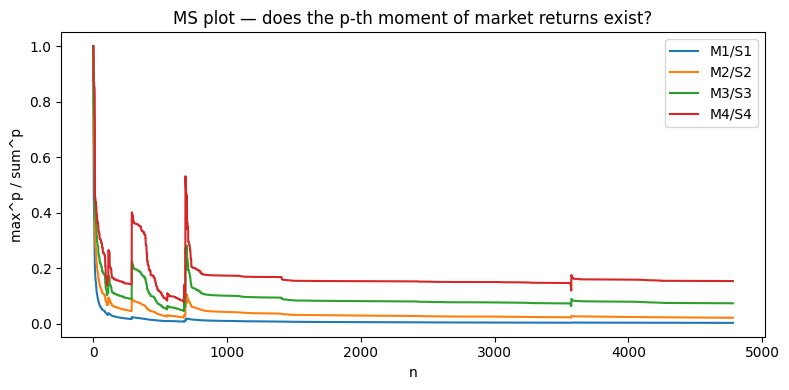

In [40]:
# ============================================================
# 9 · nnt_tails — fat-tail diagnostics (SCOFT / Taleb)
# Run per regime in the analysis notebook on within-regime returns.
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def ms_plot(x, moments=(1, 2, 3, 4)):
    """Maximum-to-Sum plot (SCOFT §2.2.21). R_n^p = max|x|^p / sum|x|^p.
    If E[|X|^p] < ∞ then R_n^p -> 0; persistence => that moment likely doesn't exist."""
    a = np.abs(np.asarray(x, float)); a = a[~np.isnan(a)]
    out = {}
    for p in moments:
        ap = a ** p
        out[f"M{p}/S{p}"] = np.maximum.accumulate(ap) / np.cumsum(ap)
    return pd.DataFrame(out, index=np.arange(1, len(a) + 1))

def mean_excess(x, n_thresholds=100):
    """Mean-excess e(u)=E[X-u | X>u]. Rising ~linearly => power-law / fat tail."""
    a = np.sort(np.asarray(x, float)); a = a[~np.isnan(a)]
    us = np.quantile(a, np.linspace(0.5, 0.98, n_thresholds))
    e = [a[a > u].mean() - u if (a > u).any() else np.nan for u in us]
    return pd.DataFrame({"threshold": us, "mean_excess": e})

def hill_estimator(x, k_frac=0.10):
    """Hill tail index. Returns alpha (=1/xi); smaller alpha = fatter tail.
    Equity returns typically alpha~3 => 4th moment suspect => kurtosis unreliable."""
    a = np.sort(np.abs(np.asarray(x, float))); a = a[a > 0]
    n = len(a)
    if n < 30:
        return {"alpha": np.nan, "xi": np.nan, "k": 0, "n": n}
    k = max(int(k_frac * n), 10)
    logs = np.log(a[-(k + 1):])
    xi = (logs[1:] - logs[0]).mean()
    return {"alpha": (1.0 / xi if xi > 0 else np.inf), "xi": xi, "k": k, "n": n}

def kurtosis_under_aggregation(x, agg_levels=(1, 2, 5, 10, 20)):
    """Excess kurtosis of non-overlapping m-day sums (SCOFT §10.2.1).
    Decays fast under Gaussian; stays high/erratic under fat tails."""
    s = pd.Series(np.asarray(x, float)).dropna()
    rows = []
    for m in agg_levels:
        agg = s.rolling(m).sum().dropna()[::m]
        rows.append({"agg_days": m, "excess_kurtosis": agg.kurtosis(), "n": len(agg)})
    return pd.DataFrame(rows)

def tail_asymmetry(x):
    """Right vs left tail Hill alpha (SCOFT §10.2.8). left_alpha<right_alpha => fatter downside."""
    a = np.asarray(x, float); a = a[~np.isnan(a)]
    r, l = hill_estimator(a[a > 0]), hill_estimator(-a[a < 0])
    return {"right_alpha": r["alpha"], "left_alpha": l["alpha"],
            "left_fatter": (l["alpha"] < r["alpha"]) if np.isfinite(l["alpha"]) and np.isfinite(r["alpha"]) else None}

print("nnt_tails loaded: ms_plot, mean_excess, hill_estimator, "
      "kurtosis_under_aggregation, tail_asymmetry")

# --- quick full-sample demo on market returns ---
r = derived["mkt_logret"].dropna().values
print("\nHill (whole sample):", hill_estimator(r))
print("Tail asymmetry:", tail_asymmetry(r))
print("\nKurtosis under aggregation:")
print(kurtosis_under_aggregation(r).to_string(index=False))

ms = ms_plot(r)
ax = ms.plot(figsize=(8, 4), title="MS plot — does the p-th moment of market returns exist?")
ax.set_xlabel("n"); ax.set_ylabel("max^p / sum^p"); plt.tight_layout(); plt.show()

Hill tail exponent (whole sample): {'alpha': np.float64(2.3284674663719582), 'xi': np.float64(0.42946702689306815), 'k': 478, 'n': 4781}
Tail asymmetry: {'right_alpha': np.float64(2.517667184429458), 'left_alpha': np.float64(2.4324673084969595), 'left_fatter': np.True_}

Kurtosis under aggregation (should stay high & erratic for fat tails):
 agg_days  excess_kurtosis    n
        1        11.931043 4781
        2        10.175044 2390
        5         6.785204  956
       10         7.849655  478
       20         8.916959  239


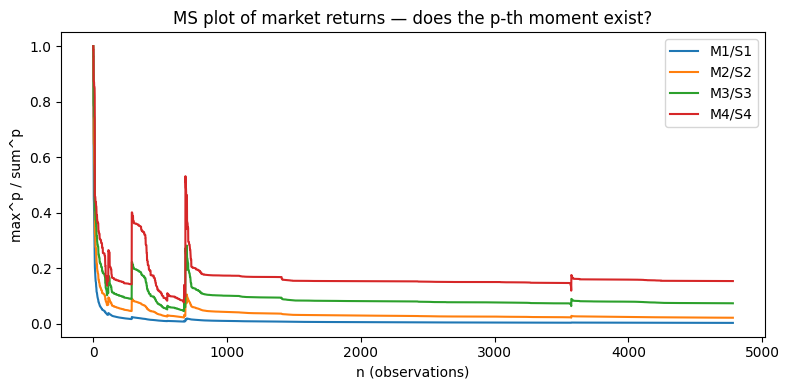

In [41]:
# Quick demo on the full-sample market returns so you can see it works end-to-end.
import matplotlib.pyplot as plt

r = derived["mkt_logret"].dropna().values

print("Hill tail exponent (whole sample):", hill_estimator(r))
print("Tail asymmetry:", tail_asymmetry(r))
print("\nKurtosis under aggregation (should stay high & erratic for fat tails):")
print(kurtosis_under_aggregation(r).to_string(index=False))

ms = ms_plot(r)
ax = ms.plot(figsize=(8, 4), title="MS plot of market returns — does the p-th moment exist?")
ax.set_xlabel("n (observations)"); ax.set_ylabel("max^p / sum^p")
plt.tight_layout(); plt.show()
# Interpretation: lines for p=3,4 that stay well above zero / jump on big days => those
# moments are not reliably finite => report tail exponent & shadow stats, not kurtosis.


## 10 · Save & manifest

Everything cached so the modelling notebooks just `pd.read_parquet`. Re-run only the cells whose
source changed.

In [43]:
# ============================================================
# 10 · Save manifest & close connection
# ============================================================
manifest = {
    "raw/fred_raw.parquet": "All FRED series (vol, rates, full-history credit BAA10Y, FCIs, macro levels)",
    "raw/crsp_market_index.parquet": "CRSP daily value-weighted market index + sprtrn (2006+)",
    "raw/crsp_sp500.parquet": "CRSP S&P 500 index level + return (dsp500_v2, 2006+)",
    "raw/virt_daily.parquet": "Virtu (VIRT) daily price/return/volume (2015 IPO+)",
    "raw/virt_fundamentals_q.parquet": "Virtu Compustat quarterly fundamentals",
    "raw/spx_ivsurface.parquet": "OptionMetrics SPX implied-vol surface (full delta grid, 2006+)",
    "raw/fomc_dates.parquet": "FOMC decision dates",
    "raw/release_calendar.parquet": "CPI/NFP/GDP/PCE/Unemployment/FOMC release dates (ALFRED first-vintage)",
    "clean/derived_vol_series.parquet": "RV, IV, VRP, vol-of-vol, RV-IV gap",
    "clean/macro_surprises.parquet": "CPI/NFP/etc surprise proxies (random-walk based)",
    "clean/spx_iv_30d_atm.parquet": "30-day ATM SPX implied vol series",
    "clean/master_daily_panel.parquet": "Aligned daily panel for regime classification",
}
mf = pd.DataFrame(
    [(k, v, (DATA_DIR / k).exists(), (round((DATA_DIR / k).stat().st_size / 1024, 1) if (DATA_DIR / k).exists() else 0))
     for k, v in manifest.items()],
    columns=["file", "description", "exists", "size_kb"])
mf.to_csv(DATA_DIR / "MANIFEST.csv", index=False)
print(mf.to_string(index=False))

missing = mf.loc[~mf["exists"], "file"].tolist()
if missing:
    print("\n*** MISSING — re-run the cell that creates these before relying on the panel:")
    for m in missing: print("   ", m)
else:
    print("\nAll 12 datasets present. Data layer complete — the analysis notebook can read parquet only.")

try:
    db.close(); print("WRDS connection closed.")
except Exception:
    pass

                            file                                                                  description  exists  size_kb
            raw/fred_raw.parquet All FRED series (vol, rates, full-history credit BAA10Y, FCIs, macro levels)    True    203.4
   raw/crsp_market_index.parquet                      CRSP daily value-weighted market index + sprtrn (2006+)    True    223.5
          raw/crsp_sp500.parquet                         CRSP S&P 500 index level + return (dsp500_v2, 2006+)    True    121.7
          raw/virt_daily.parquet                           Virtu (VIRT) daily price/return/volume (2015 IPO+)    True    112.4
 raw/virt_fundamentals_q.parquet                                       Virtu Compustat quarterly fundamentals    True     12.1
       raw/spx_ivsurface.parquet               OptionMetrics SPX implied-vol surface (full delta grid, 2006+)    True   5391.7
          raw/fomc_dates.parquet                                                          FOMC decision dates  

---
### Next notebook (analysis) — what plugs into this
1. **Regime classifier** on `master_daily_panel.parquet`: rule-based buckets first
   (hawkish-inflationary, dovish-stable, growth-scare, policy-transition) using `cpi_yoy`,
   `fedfunds_upper` direction, `t10y2y`, `nfp_chg`, `hy_oas`, `nfci`; optionally a
   Gaussian-mixture / HMM cross-check.
2. **Per-regime VRP & RV−IV**: when is `rv_minus_iv_1m` positive (implied underpriced realized)?
3. **Per-regime `nnt_tails`**: MS plot, Hill α, tail asymmetry, kurtosis-under-aggregation on
   within-regime returns — *this* is the SCOFT contribution that distinguishes your project.
4. **Map to Virtu**: align `virt_fundamentals_q` revenue volatility / cash buffers to
   macro-event density per quarter (the proposal's empirical link).
5. **Operational output**: per-regime inventory / spread-widening / hedging-intensity table —
   the *Dynamic Hedging* deliverable.
